# Week 5 - Day 3: Dimensionality Reduction with PCA

**Goal:** Reduce the Wine dataset's 13 features down to a handful of principal components, understand how much information (variance) is preserved at each step, and visualize the data in 2D.

**Dataset:** Wine dataset (same as Day 1-2) — 178 samples, 13 chemical measurements, scaled with `StandardScaler`.


## Step 1: Load and Scale the Data (Same as Day 1-2)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
true_labels = data.target  # used only for coloring the final plot, not for PCA itself

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Original shape: {X_scaled.shape}  -->  13 features per sample")


Original shape: (178, 13)  -->  13 features per sample


## Step 2: Fit PCA and Plot Cumulative Explained Variance

PCA requires scaled data, since it's variance-based — an unscaled high-range feature would appear artificially important. We already scaled in Step 1.


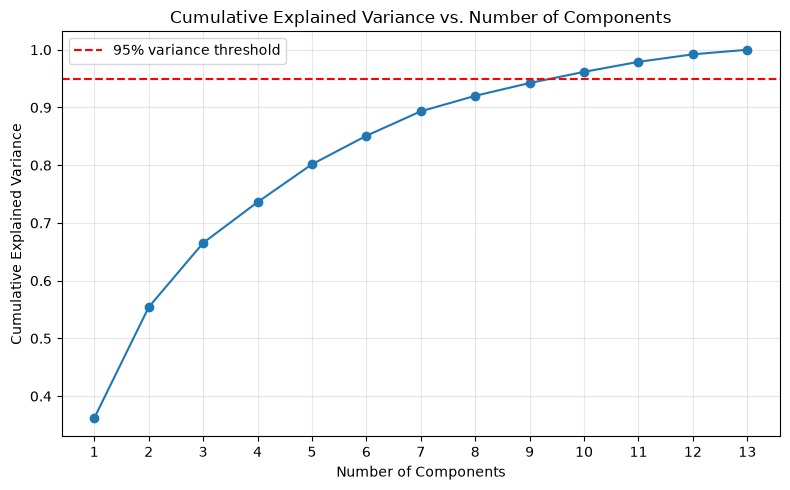

Component  1: explains 0.3620  |  cumulative 0.3620
Component  2: explains 0.1921  |  cumulative 0.5541
Component  3: explains 0.1112  |  cumulative 0.6653
Component  4: explains 0.0707  |  cumulative 0.7360
Component  5: explains 0.0656  |  cumulative 0.8016
Component  6: explains 0.0494  |  cumulative 0.8510
Component  7: explains 0.0424  |  cumulative 0.8934
Component  8: explains 0.0268  |  cumulative 0.9202
Component  9: explains 0.0222  |  cumulative 0.9424
Component 10: explains 0.0193  |  cumulative 0.9617
Component 11: explains 0.0174  |  cumulative 0.9791
Component 12: explains 0.0130  |  cumulative 0.9920
Component 13: explains 0.0080  |  cumulative 1.0000


In [3]:
from sklearn.decomposition import PCA

# Fit PCA keeping ALL components first, just to see how variance is distributed
pca_full = PCA(n_components=X_scaled.shape[1], random_state=42)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative) + 1), cumulative, marker="o")
plt.axhline(y=0.95, color="red", linestyle="--", label="95% variance threshold")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs. Number of Components")
plt.xticks(range(1, len(cumulative) + 1))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for i, (e, c) in enumerate(zip(explained, cumulative), start=1):
    print(f"Component {i:2d}: explains {e:.4f}  |  cumulative {c:.4f}")


## Step 3: Choose the Number of Components That Retains ~95% of the Variance

In [4]:
n_components_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Number of components needed to retain at least 95% of the variance: {n_components_95}")
print(f"Cumulative variance retained with {n_components_95} components: {cumulative[n_components_95 - 1]:.4f}")


Number of components needed to retain at least 95% of the variance: 10
Cumulative variance retained with 10 components: 0.9617


### Reflection — Justifying the Component Count



Going from 13 original features down to 10 components still keeps at least 95% of the total variance in the data — but that's a modest reduction, not a dramatic one. This tells us something useful: the wine dataset's 13 chemical measurements don't have a huge amount of redundancy between them, so most of the original dimensions are each contributing real, non-overlapping information. PCA still helps (10 is fewer than 13), but this dataset wouldn't be a strong candidate for aggressive compression if 95% retention were the goal — it's more useful here for visualization (Step 4) than for major dimensionality reduction.


## Step 4: Reduce to 2 Components and Visualize

Variance explained by these 2 components alone: 0.5541


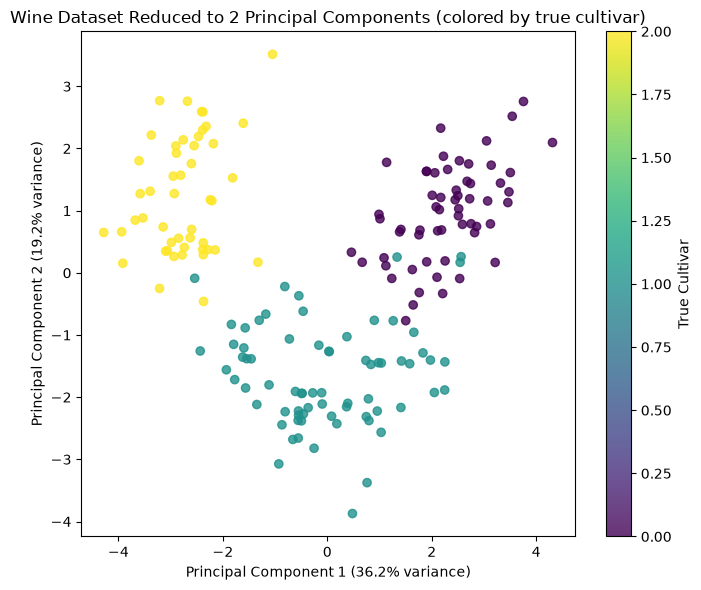

In [5]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"Variance explained by these 2 components alone: {pca_2d.explained_variance_ratio_.sum():.4f}")

plt.figure(figsize=(7, 6))
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=true_labels, cmap="viridis", alpha=0.8)
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)")
plt.title("Wine Dataset Reduced to 2 Principal Components (colored by true cultivar)")
plt.colorbar(scatter, label="True Cultivar")
plt.tight_layout()
plt.show()


### Reflection — What Does This 2D View Show?



Even after collapsing all 13 chemical measurements down to just 2 components, the three wine cultivars (shown here only for coloring, not used by PCA itself) separate into visually distinct regions. This confirms that a large part of what actually distinguishes the cultivars is captured by just these two combined directions of variance — a strong result for only 2 out of 13 original dimensions.


## Step 5: What the Reduction Preserved vs. What It Cost

In [6]:
print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"Dimensions needed for 95% variance: {n_components_95}")
print(f"Variance kept by 2 components alone: {pca_2d.explained_variance_ratio_.sum():.1%}")
print(f"Variance lost by using only 2 components: {1 - pca_2d.explained_variance_ratio_.sum():.1%}")


Original dimensions: 13
Dimensions needed for 95% variance: 10
Variance kept by 2 components alone: 55.4%
Variance lost by using only 2 components: 44.6%


### Reflection — Trade-Offs of the Reduction



**What it preserved:** Most of the meaningful structure in the data — the components that capture the most spread also happen to separate the true wine cultivars clearly, so the reduction kept the information that actually matters for distinguishing the wines.

**What it cost:** Interpretability. Each principal component is a mathematical combination of all 13 original features (weighted differently), so "Principal Component 1" doesn't correspond to a single understandable chemical property the way "alcohol" or "color intensity" did in Day 1-2. We gained a much smaller, visualizable dataset, but lost the ability to explain a result in terms of one specific original measurement without digging into the component's feature weights.


## Summary

| Step | Result |
|---|---|
| Original dimensions | 13 |
| Components needed for ~95% variance | see Step 3 output |
| Variance kept by just 2 components | see Step 4 output |

- PCA requires scaled input, since it is a variance-based technique.
- The cumulative explained variance plot shows how quickly information is captured as components are added.
- Reducing to just 2 components still visually separated the true wine cultivars, even though PCA never saw those labels.
- The trade-off: fewer, more manageable dimensions, but each new "feature" (component) is a combination of the originals and loses direct interpretability.
- Next (Day 4): t-SNE for a different kind of visualization (local structure instead of global variance), and anomaly detection with Isolation Forest.
